# Proyecto PENGWIN - Notebook acumulativo

Este es el unico notebook del proyecto. Reune de forma progresiva la carga del dataset medico `.mha`, verificacion imagen-label, splits fijos, ventaneo HU, EDA, visualizacion 3D, preparacion de datos y targets, y las etapas de modelado que se incorporen en los siguientes avances.

La ejecucion es reproducible desde la raiz del repositorio y utiliza exclusivamente rutas relativas. Los datos locales deben estar en `data_mha/`.

## 1. Librerias base

Se importan las librerias necesarias para trabajar con rutas, tablas, volumenes medicos, arreglos numericos y graficas.

In [1]:
from pathlib import Path
import pandas as pd
import SimpleITK as sitk
import numpy as np
import random
import matplotlib.pyplot as plt

## 2. Configuracion de rutas reproducibles

Todas las rutas se construyen desde `Path.cwd()`, es decir, desde la raiz del repositorio. Esto evita rutas absolutas de un computador especifico y permite que cualquier integrante ejecute el notebook si conserva la estructura esperada.

In [2]:
BASE_DIR = Path.cwd()

DATA_MHA_DIR = BASE_DIR / "data_mha"

IMAGE_DIRS = [
    DATA_MHA_DIR / "PENGWIN_CT_train_images_part1",
    DATA_MHA_DIR / "PENGWIN_CT_train_images_part2",
]

LABELS_DIR = DATA_MHA_DIR / "PENGWIN_CT_train_labels"
LABEL_DIR = LABELS_DIR  # Alias para compatibilidad con celdas anteriores
SPLITS_DIR = BASE_DIR / "splits"
EVIDENCE_DIR = BASE_DIR / "evidencias"
GENERATED_DATA_DIR = EVIDENCE_DIR / "datos"

SPLITS_DIR.mkdir(exist_ok=True)
EVIDENCE_DIR.mkdir(exist_ok=True)
GENERATED_DATA_DIR.mkdir(parents=True, exist_ok=True)


def to_repo_relative(path):
    """Guarda rutas portables dentro del repositorio."""
    path = Path(path)
    try:
        return path.relative_to(BASE_DIR).as_posix()
    except ValueError:
        return path.as_posix()


def resolve_repo_path(path):
    """Permite leer rutas relativas o absolutas sin romper compatibilidad."""
    path = Path(path)
    if path.is_absolute():
        return path
    return BASE_DIR / path


## 3. Conteo inicial de archivos `.mha`

Se buscan las imagenes CT y las mascaras/labels locales. En esta entrega los datos pesados no se suben a GitHub; cada integrante debe tenerlos en `data_mha/`.

In [3]:
image_files = []

for image_dir in IMAGE_DIRS:
    image_files.extend(image_dir.glob("*.mha"))

image_files = sorted(image_files)
label_files = sorted(LABELS_DIR.glob("*.mha"))

print("RESUMEN DEL DATASET")


print(f"Imágenes encontradas: {len(image_files)}")
print(f"Labels encontrados:   {len(label_files)}")

RESUMEN DEL DATASET
Imágenes encontradas: 100
Labels encontrados:   100


## 4. Extraccion de IDs de casos

Se extraen los IDs desde los nombres de archivo para comparar imagenes y labels sin depender de rutas completas.

In [4]:
image_ids = {
    file.stem
    for file in image_files
}

label_ids = {
    file.stem
    for file in label_files
}

## 5. Validacion de correspondencia imagen-label

Se comprueba que cada imagen tenga su label y que no existan labels sin imagen. Esta validacion es la base del dataset curado.

In [5]:
images_without_labels = sorted(image_ids - label_ids)
labels_without_images = sorted(label_ids - image_ids)

common_ids = sorted(image_ids & label_ids)

print("VALIDACIÓN DE CORRESPONDENCIA")

print(f"Casos con imagen + label: {len(common_ids)}")

print(
    f"Imágenes sin label:       {len(images_without_labels)}"
)

print(
    f"Labels sin imagen:        {len(labels_without_images)}"
)


if images_without_labels:
    print("\nImágenes sin label:")
    for case_id in images_without_labels:
        print(f"  - {case_id}")


if labels_without_images:
    print("\nLabels sin imagen:")
    for case_id in labels_without_images:
        print(f"  - {case_id}")


VALIDACIÓN DE CORRESPONDENCIA
Casos con imagen + label: 100
Imágenes sin label:       0
Labels sin imagen:        0


## 6. Construccion del dataset curado

Se crea una tabla con `case_id`, ruta relativa de imagen y ruta relativa de label. Las rutas se guardan relativas al repositorio para mantener reproducibilidad entre computadores.

In [6]:
dataset = []

for case_id in common_ids:

    # Buscar la imagen en todas las partes
    image_path = None

    for image_dir in IMAGE_DIRS:
        possible_path = image_dir / f"{case_id}.mha"

        if possible_path.exists():
            image_path = possible_path
            break

    # Ruta del label
    label_path = LABELS_DIR / f"{case_id}.mha"

    # Verificar que ambos existan
    if image_path is not None and label_path.exists():

        dataset.append({
            "case_id": case_id,
            "image_path": to_repo_relative(image_path),
            "label_path": to_repo_relative(label_path)
        })


df = pd.DataFrame(dataset)
df


,case_id,image_path,label_path
0,001,data_mha/PENGWIN_CT_train_images_part1/001.mha,data_mha/PENGWIN_CT_train_labels/001.mha
1,002,data_mha/PENGWIN_CT_train_images_part1/002.mha,data_mha/PENGWIN_CT_train_labels/002.mha
2,003,data_mha/PENGWIN_CT_train_images_part1/003.mha,data_mha/PENGWIN_CT_train_labels/003.mha
3,004,data_mha/PENGWIN_CT_train_images_part1/004.mha,data_mha/PENGWIN_CT_train_labels/004.mha
4,005,data_mha/PENGWIN_CT_train_images_part1/005.mha,data_mha/PENGWIN_CT_train_labels/005.mha
...,...,...,...
95,096,data_mha/PENGWIN_CT_train_images_part2/096.mha,data_mha/PENGWIN_CT_train_labels/096.mha
96,097,data_mha/PENGWIN_CT_train_images_part2/097.mha,data_mha/PENGWIN_CT_train_labels/097.mha
97,098,data_mha/PENGWIN_CT_train_images_part2/098.mha,data_mha/PENGWIN_CT_train_labels/098.mha
98,099,data_mha/PENGWIN_CT_train_images_part2/099.mha,data_mha/PENGWIN_CT_train_labels/099.mha


## 7. Exportacion de `dataset.csv`

Se guarda el dataset curado en `splits/dataset.csv`. Este archivo queda versionado en GitHub porque contiene rutas ligeras y reproducibles, no datos pesados.

In [7]:
dataset_path = SPLITS_DIR / "dataset.csv"

df.to_csv(
    dataset_path,
    index=False
)

print()
print(f"Dataset curado guardado en:")
print(dataset_path)


Dataset curado guardado en:
/Users/danielamarinvillacorte/Documents/Analítica de datos/02_clases/Clases/Ferro/Proyecto_Corte2_PENGWIN/splits/dataset.csv


## 8. Verificacion tecnica de volumenes `.mha`

Se cargan imagen y label con SimpleITK para verificar dimensiones, spacing, origen y direccion. Esto confirma que las mascaras corresponden fisicamente con las tomografias.

In [8]:
records = []

for _, row in df.iterrows():

    image = sitk.ReadImage(str(resolve_repo_path(row["image_path"])))
    label = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))

    records.append({
        "case_id": row["case_id"],

        # Imagen
        "image_dimension": image.GetDimension(),
        "image_size": image.GetSize(),
        "image_spacing": image.GetSpacing(),

        # Label
        "label_dimension": label.GetDimension(),
        "label_size": label.GetSize(),
        "label_spacing": label.GetSpacing(),

        # Verificaciones
        "same_size": image.GetSize() == label.GetSize(),
        "same_spacing": image.GetSpacing() == label.GetSpacing(),
        "same_direction": image.GetDirection() == label.GetDirection(),
        "same_origin": image.GetOrigin() == label.GetOrigin()
    })

verification_df = pd.DataFrame(records)

verification_df.head(20)


,case_id,image_dimension,image_size,image_spacing,label_dimension,label_size,label_spacing,same_size,same_spacing,same_direction,same_origin
0,001,3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",True,True,True,True
1,002,3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",True,True,True,True
2,003,3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",True,True,True,True
3,004,3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",True,True,True,True
4,005,3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",True,True,True,True
5,006,3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",True,True,True,True
6,007,3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",True,True,True,True
7,008,3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",True,True,True,True
8,009,3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",True,True,True,True
9,010,3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",True,True,True,True


## 9. Resumen de consistencia del dataset

Se resumen las verificaciones anteriores para confirmar que el dataset local esta completo y alineado.

In [9]:
print("Casos:", len(verification_df))

print("\nDimensiones de las imágenes:")
print(verification_df["image_dimension"].value_counts())

print("\nDimensiones de los labels:")
print(verification_df["label_dimension"].value_counts())

print("\nTamaños CT-label iguales:")
print(verification_df["same_size"].value_counts())

print("\nSpacing CT-label iguales:")
print(verification_df["same_spacing"].value_counts())

Casos: 100

Dimensiones de las imágenes:
image_dimension
3    100
Name: count, dtype: int64

Dimensiones de los labels:
label_dimension
3    100
Name: count, dtype: int64

Tamaños CT-label iguales:
same_size
True    100
Name: count, dtype: int64

Spacing CT-label iguales:
same_spacing
True    100
Name: count, dtype: int64


## 10. Conteo inicial de fragmentos por caso

A partir de las labels se cuenta cuantas etiquetas diferentes aparecen en cada caso, excluyendo el fondo. Esto da una primera idea de la complejidad del dataset.

In [10]:
frag_counts = []

for _, row in df.iterrows():
    label_img = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    label_vol = sitk.GetArrayFromImage(label_img)
    n_fragments = len(np.unique(label_vol)) - 1  # excluir fondo (label 0)
    frag_counts.append(n_fragments)

df["n_fragments"] = frag_counts

print("Distribucion de numero de fragmentos por caso:")
print(df["n_fragments"].describe())
print("\nConteo de valores (cuantos casos tienen cada n de fragmentos):")
print(df["n_fragments"].value_counts().sort_index())

Distribucion de numero de fragmentos por caso:
count    100.000000
mean       5.750000
std        1.217507
min        3.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: n_fragments, dtype: float64

Conteo de valores (cuantos casos tienen cada n de fragmentos):
n_fragments
3     1
4    13
5    32
6    28
7    18
8     6
9     2
Name: count, dtype: int64


## 11. Splits fijos

Se usa una particion 75/5/20: 75 casos para entrenamiento, 5 para validacion y 20 para test. La semilla fija permite reproducir siempre los mismos splits.

In [11]:
from sklearn.model_selection import train_test_split

SEED = 42


def complexity_bin(n_fragments):
    if n_fragments <= 4:
        return "baja"
    if n_fragments <= 6:
        return "media"
    return "alta"

split_source = df[["case_id", "image_path", "label_path", "n_fragments"]].copy()
split_source["complexity"] = split_source["n_fragments"].apply(complexity_bin)

train_val_df, test_df = train_test_split(
    split_source,
    test_size=20,
    random_state=SEED,
    shuffle=True,
    stratify=split_source["complexity"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=5,
    random_state=SEED,
    shuffle=True,
    stratify=train_val_df["complexity"],
)

splits = {
    "train": train_df.sort_values("case_id"),
    "val": val_df.sort_values("case_id"),
    "test": test_df.sort_values("case_id"),
}

for name, split_df in splits.items():
    (SPLITS_DIR / f"{name}.txt").write_text("\n".join(split_df["case_id"].tolist()) + "\n")

split_dataset = []
for name, split_df in splits.items():
    temp = split_df.copy()
    temp.insert(1, "split", name)
    split_dataset.append(temp)

split_dataset = pd.concat(split_dataset, ignore_index=True).sort_values("case_id")
split_dataset.to_csv(SPLITS_DIR / "dataset.csv", index=False)

print("Splits fijos con semilla:", SEED)
print(split_dataset["split"].value_counts().reindex(["train", "val", "test"]))
print("\nDistribucion por complejidad:")
print(split_dataset.groupby(["split", "complexity"]).size().unstack(fill_value=0))


Splits fijos con semilla: 42
split
train    75
val       5
test     20
Name: count, dtype: int64

Distribucion por complejidad:
complexity  alta  baja  media
split                        
test           5     3     12
train         20    10     45
val            1     1      3


## 12. Ventaneo HU para visualizacion de hueso

Se define una ventana osea aproximada usando centro 400 HU y ancho 1800 HU. El objetivo es redistribuir intensidades para resaltar hueso y justificar el preprocesamiento con valores HU.

In [12]:
def load_mha(path):
    image = sitk.ReadImage(str(resolve_repo_path(path)))
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # orden (z, y, x)
    spacing = tuple(float(value) for value in image.GetSpacing())  # (x, y, z) mm
    return volume, spacing


def apply_hu_window(volume, window_center=400, window_width=1800):
    low = window_center - window_width / 2
    high = window_center + window_width / 2
    windowed = np.clip(volume, low, high)
    windowed = (windowed - low) / (high - low)
    return windowed

# prueba rapida sobre un caso MHA
volume, spacing = load_mha(df.loc[0, "image_path"])
windowed = apply_hu_window(volume)
print(f"Caso {df.loc[0, 'case_id']}: spacing={spacing}, "
      f"rango original=({volume.min():.1f}, {volume.max():.1f}), "
      f"rango ventaneado=({windowed.min():.2f}, {windowed.max():.2f})")

Caso 001: spacing=(0.78125, 0.78125, 0.800000011920929), rango original=(-1023.0, 2775.0), rango ventaneado=(0.00, 1.00)


## 13. Comparacion visual antes y despues del ventaneo

Se muestra un corte del caso 001 sin ventanear y con ventana osea. Esta evidencia ayuda a explicar por que el ventaneo mejora la discriminacion visual del hueso.

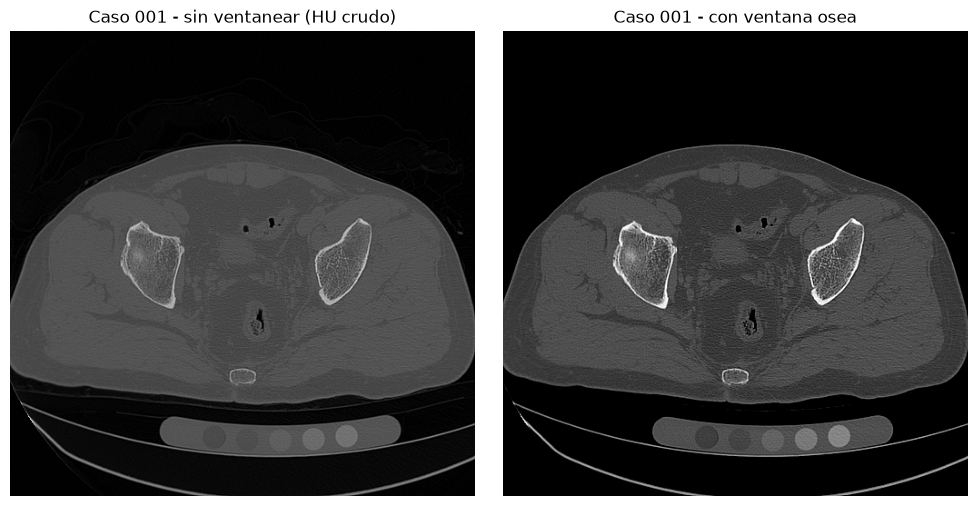

In [13]:
case_id = "001"
row = df[df["case_id"] == case_id].iloc[0]

volume, spacing = load_mha(row["image_path"])
windowed = apply_hu_window(volume)

# SimpleITK entrega el volumen en orden (z, y, x)
mid_slice = volume.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(volume[mid_slice], cmap="gray")
axes[0].set_title(f"Caso {case_id} - sin ventanear (HU crudo)")
axes[0].axis("off")

axes[1].imshow(windowed[mid_slice], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Caso {case_id} - con ventana osea")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 14. EDA de fragmentos por region anatomica

Se asigna cada label a una region anatomica aproximada: sacro, coxal izquierdo o coxal derecho. Luego se calcula el volumen fisico de cada fragmento usando el spacing en milimetros.

In [14]:
def label_to_region(label):
    if label == 0:
        return "background"
    if 1 <= label <= 10:
        return "sacro"
    if 11 <= label <= 20:
        return "coxal_izquierdo"
    if 21 <= label <= 30:
        return "coxal_derecho"
    return "desconocido"


fragment_rows = []

for _, row in df.iterrows():
    label_img = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    label_vol = sitk.GetArrayFromImage(label_img)
    spacing = tuple(float(value) for value in label_img.GetSpacing())
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]

    labels_present = np.unique(label_vol)
    labels_present = labels_present[labels_present != 0]

    for lab in labels_present:
        n_voxels = int(np.sum(label_vol == lab))
        fragment_rows.append({
            "case_id": row["case_id"],
            "label": int(lab),
            "region": label_to_region(int(lab)),
            "n_voxels": n_voxels,
            "volume_mm3": n_voxels * voxel_volume_mm3,
        })

frag_df = pd.DataFrame(fragment_rows)
frag_df.to_csv(GENERATED_DATA_DIR / "metadata_fragments.csv", index=False)
print(f"Total de fragmentos individuales en el dataset: {len(frag_df)}")
frag_df.head(10)

Total de fragmentos individuales en el dataset: 575


,case_id,label,region,n_voxels,volume_mm3
0,001,1,sacro,458539,223895.999430
1,001,11,coxal_izquierdo,762194,372165.044608
2,001,12,coxal_izquierdo,63957,31229.004372
3,001,21,coxal_derecho,844349,412279.791300
4,002,1,sacro,323928,176044.906041
5,002,2,sacro,39087,21242.582433
6,002,11,coxal_izquierdo,502549,273119.926299
7,002,21,coxal_derecho,470491,255697.389198
8,002,22,coxal_derecho,15260,8293.340700
9,002,23,coxal_derecho,19132,10397.653622


## 15. Resumen general del EDA

Se reporta el numero total de fragmentos y su distribucion por caso. Esto permite identificar si hay casos simples y casos mas complejos.

In [15]:
print("=== RESUMEN GENERAL ===")
print(f"Total de fragmentos (todas las regiones, todos los casos): {len(frag_df)}")
print(f"Fragmentos por caso -> min: {frag_df.groupby('case_id').size().min()}, "
      f"max: {frag_df.groupby('case_id').size().max()}, "
      f"media: {frag_df.groupby('case_id').size().mean():.2f}")

print("\n=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===")
print(frag_df["region"].value_counts())

print("\n=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===")
frag_por_region_caso = frag_df.groupby(["case_id", "region"]).size().reset_index(name="n_fragmentos")
print(frag_por_region_caso.groupby("region")["n_fragmentos"].describe())

=== RESUMEN GENERAL ===
Total de fragmentos (todas las regiones, todos los casos): 575
Fragmentos por caso -> min: 3, max: 9, media: 5.75

=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===
region
coxal_izquierdo    215
coxal_derecho      207
sacro              153
Name: count, dtype: int64

=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===
                 count  mean       std  min  25%  50%  75%  max
region                                                         
coxal_derecho    100.0  2.07  0.987344  1.0  1.0  2.0  3.0  4.0
coxal_izquierdo  100.0  2.15  1.067187  1.0  1.0  2.0  3.0  6.0
sacro            100.0  1.53  0.658357  1.0  1.0  1.0  2.0  4.0


## 16. Analisis de volumen de fragmentos

Se revisa la distribucion de volumenes en mm3. Los fragmentos muy pequenos pueden representar retos para segmentacion y metricas.

In [16]:
print("=== VOLUMEN DE FRAGMENTOS (mm³) ===")
print(frag_df["volume_mm3"].describe())

# Fragmentos sospechosamente pequeños (posible ruido de anotación vs. fragmento real)
umbral_pequeno = frag_df["volume_mm3"].quantile(0.05)  # percentil 5 más chico
pequenos = frag_df[frag_df["volume_mm3"] < umbral_pequeno]
print(f"\nFragmentos por debajo del percentil 5 de volumen (<{umbral_pequeno:.1f} mm³): {len(pequenos)}")
print(pequenos[["case_id", "region", "label", "volume_mm3"]].sort_values("volume_mm3").head(10))

=== VOLUMEN DE FRAGMENTOS (mm³) ===
count       575.000000
mean     135836.241955
std      114659.517155
min         282.212597
25%       23250.124644
50%      128182.935724
75%      234834.021490
max      416131.106541
Name: volume_mm3, dtype: float64

Fragmentos por debajo del percentil 5 de volumen (<3145.0 mm³): 29
    case_id           region  label   volume_mm3
299     052    coxal_derecho     23   282.212597
482     085            sacro      2   313.483475
215     038    coxal_derecho     23   518.747187
430     075  coxal_izquierdo     13   641.070251
329     057  coxal_izquierdo     13   683.141804
122     023  coxal_izquierdo     12   807.295788
478     084  coxal_izquierdo     14   812.787437
205     037            sacro      2   947.445813
477     084  coxal_izquierdo     13  1040.887642
312     054    coxal_derecho     24  1190.747253


## 17. Fragmento principal por hueso

Para cada caso y region, se identifica el fragmento de mayor volumen como fragmento principal. Los demas fragmentos se consideran conminutos para analisis posterior.

In [17]:
def get_main_fragment_per_bone(frag_df):
    rows = []
    for (case_id, region), group in frag_df.groupby(["case_id", "region"]):
        if region == "background":
            continue
        main_frag = group.loc[group["volume_mm3"].idxmax()]
        rows.append({
            "case_id": case_id,
            "region": region,
            "main_label": main_frag["label"],
            "main_volume_mm3": main_frag["volume_mm3"],
            "n_fragmentos_totales": len(group),
            "n_fragmentos_conminutos": len(group) - 1,
        })
    return pd.DataFrame(rows)

main_frag_df = get_main_fragment_per_bone(frag_df)
main_frag_df.to_csv(GENERATED_DATA_DIR / "main_fragments.csv", index=False)
main_frag_df.head(10)


,case_id,region,main_label,main_volume_mm3,n_fragmentos_totales,n_fragmentos_conminutos
0,001,coxal_derecho,21,412279.791300,1,0
1,001,coxal_izquierdo,11,372165.044608,2,1
2,001,sacro,1,223895.999430,1,0
3,002,coxal_derecho,21,255697.389198,3,2
4,002,coxal_izquierdo,11,273119.926299,1,0
5,002,sacro,1,176044.906041,2,1
6,003,coxal_derecho,21,281041.536819,1,0
7,003,coxal_izquierdo,11,236036.146324,4,3
8,003,sacro,1,181401.174675,1,0
9,004,coxal_derecho,21,214046.217773,2,1


## 18. Huesos fracturados y no fracturados por region

Se resume cuantos huesos tienen un solo fragmento y cuantos presentan multiples fragmentos por region anatomica.

In [18]:
print("=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===")
sin_fractura = main_frag_df[main_frag_df["n_fragmentos_totales"] == 1]
print(sin_fractura["region"].value_counts())

print("\n=== % de huesos fracturados por región ===")
total_por_region = main_frag_df["region"].value_counts()
fracturados_por_region = main_frag_df[main_frag_df["n_fragmentos_totales"] > 1]["region"].value_counts()
pct_fracturado = (fracturados_por_region / total_por_region * 100).round(1)
print(pct_fracturado)

=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===
region
sacro              55
coxal_derecho      36
coxal_izquierdo    34
Name: count, dtype: int64

=== % de huesos fracturados por región ===
region
coxal_derecho      64.0
coxal_izquierdo    66.0
sacro              45.0
Name: count, dtype: float64


## 19. Graficas exploratorias del EDA

Se generan graficas para visualizar fragmentos por caso, volumen por region y distribuciones generales del dataset.

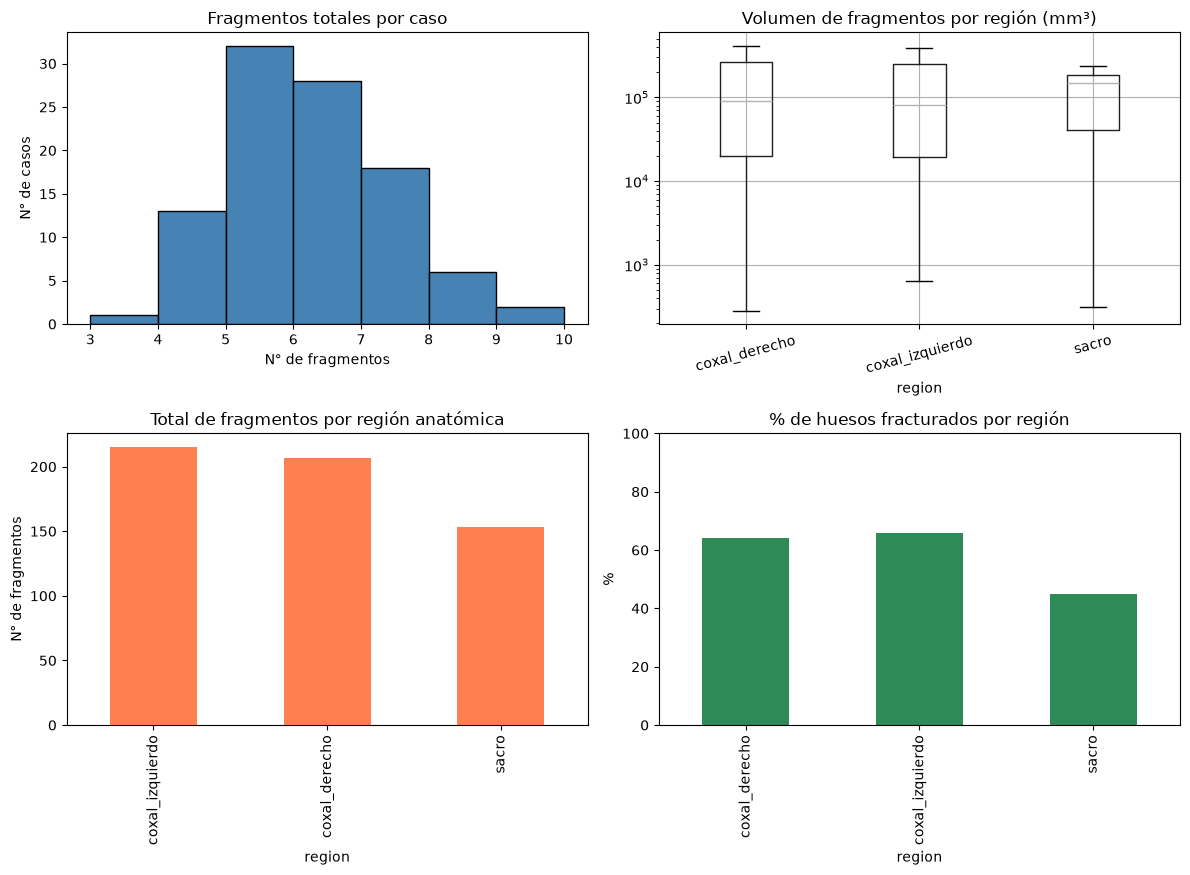

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Histograma: n° de fragmentos por caso (a nivel dataset completo)
frag_por_caso = frag_df.groupby("case_id").size()
axes[0, 0].hist(frag_por_caso, bins=range(frag_por_caso.min(), frag_por_caso.max() + 2), 
                 edgecolor="black", color="steelblue")
axes[0, 0].set_title("Fragmentos totales por caso")
axes[0, 0].set_xlabel("N° de fragmentos")
axes[0, 0].set_ylabel("N° de casos")

# Boxplot: volumen de fragmento por región
frag_df.boxplot(column="volume_mm3", by="region", ax=axes[0, 1])
axes[0, 1].set_title("Volumen de fragmentos por región (mm³)")
axes[0, 1].set_yscale("log")  # log porque probablemente hay outliers grandes
plt.sca(axes[0, 1])
plt.xticks(rotation=15)

# Barras: cantidad de fragmentos por región (total dataset)
frag_df["region"].value_counts().plot(kind="bar", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Total de fragmentos por región anatómica")
axes[1, 0].set_ylabel("N° de fragmentos")

# Barras: % de huesos fracturados por región
pct_fracturado.plot(kind="bar", ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("% de huesos fracturados por región")
axes[1, 1].set_ylabel("%")
axes[1, 1].set_ylim(0, 100)

plt.suptitle("")  # quita el título automático feo que pone pandas
plt.tight_layout()
plt.show()

## 20. Visualizacion volumetrica inicial

A partir de aqui se construye la evidencia visual del volumen crudo. Se incluyen MIP y una reconstruccion por malla dentro de este mismo notebook, siguiendo la recomendacion de pasar de puntos a superficies.

### 20.1 MIP raw

Se define una proyeccion de maxima intensidad usando un umbral HU para hueso. El MIP conserva, para cada direccion, los voxeles de mayor intensidad y permite una vista volumetrica inicial.

In [20]:
def compute_mip(volume, hu_threshold=300, axis=0):
    """Proyeccion de maxima intensidad sobre el volumen MHA (z, y, x).

    axis=0: axial; axis=1: coronal; axis=2: sagital.
    """
    bone_only = np.where(volume > hu_threshold, volume, 0)
    return np.max(bone_only, axis=axis)

### 20.2 MIP en tres vistas

Se generan vistas axial, coronal y sagital del caso 001. Esta evidencia complementa el visualizador 3D y ayuda a documentar el volumen crudo.

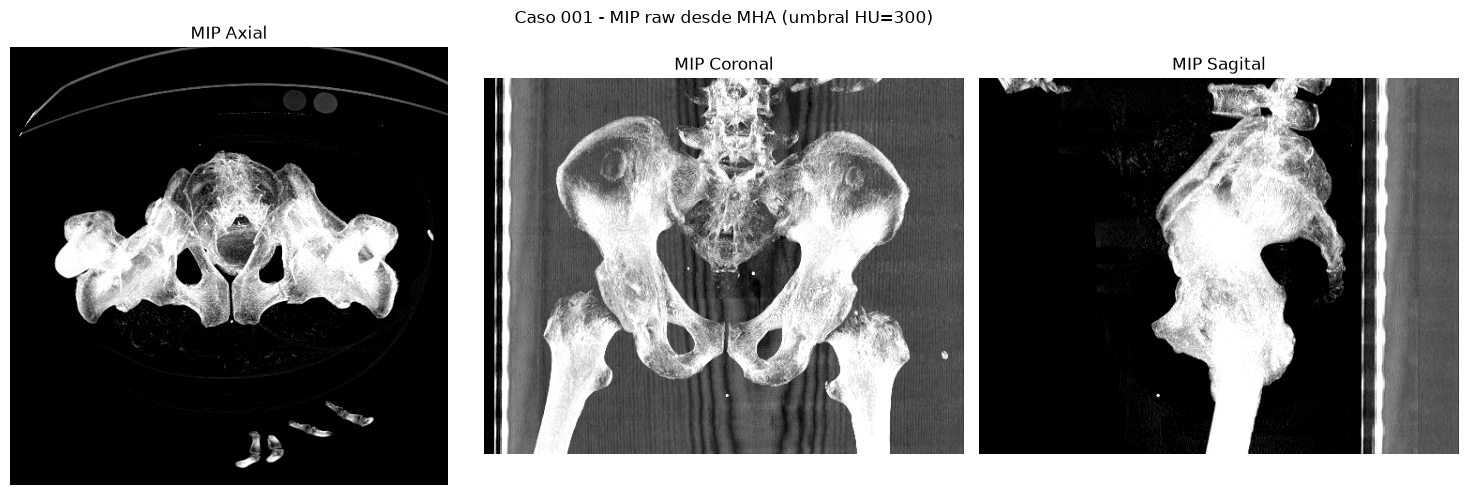

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# El volumen cargado con SimpleITK usa orden (z, y, x)
mip_axial = compute_mip(volume, hu_threshold=300, axis=0)
mip_coronal = compute_mip(volume, hu_threshold=300, axis=1)
mip_sagital = compute_mip(volume, hu_threshold=300, axis=2)

vmax_hueso = 1500

axes[0].imshow(mip_axial, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[0].set_title("MIP Axial")
axes[0].axis("off")

axes[1].imshow(mip_coronal, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[1].set_title("MIP Coronal")
axes[1].axis("off")

axes[2].imshow(mip_sagital, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[2].set_title("MIP Sagital")
axes[2].axis("off")

plt.suptitle(f"Caso {case_id} - MIP raw desde MHA (umbral HU=300)")
plt.tight_layout()
plt.show()

### 20.3 Malla 3D interactiva

Se reconstruyen las superficies del sacro y los dos coxales mediante marching cubes. La malla permite rotar, desplazar y acercar el volumen, evitando la nube de puntos ruidosa del prototipo inicial. El HTML es una evidencia generada por este notebook.

In [22]:
import plotly.graph_objects as go
from skimage import measure

REGIONES_MALLA = {
    "sacro": {"labels": range(1, 11), "color": "#D9A62E"},
    "coxal_izquierdo": {"labels": range(11, 21), "color": "#2B8CBE"},
    "coxal_derecho": {"labels": range(21, 31), "color": "#E34A33"},
}


def crop_to_nonzero(mask, margin=8):
    coordinates = np.argwhere(mask)
    if len(coordinates) == 0:
        return None
    lower = np.maximum(coordinates.min(axis=0) - margin, 0)
    upper = np.minimum(coordinates.max(axis=0) + margin + 1, mask.shape)
    z0, y0, x0 = lower
    z1, y1, x1 = upper
    return mask[z0:z1, y0:y1, x0:x1], lower


def mesh_from_mask(mask, spacing_xyz, origin_zyx, stride=2):
    sampled = mask[::stride, ::stride, ::stride]
    spacing_zyx = (
        spacing_xyz[2] * stride,
        spacing_xyz[1] * stride,
        spacing_xyz[0] * stride,
    )
    vertices, faces, _, _ = measure.marching_cubes(
        sampled.astype(np.uint8), level=0.5, spacing=spacing_zyx
    )
    z = vertices[:, 0] + origin_zyx[0] * spacing_xyz[2]
    y = vertices[:, 1] + origin_zyx[1] * spacing_xyz[1]
    x = vertices[:, 2] + origin_zyx[2] * spacing_xyz[0]
    return x, y, z, faces


label_image = sitk.ReadImage(str(LABELS_DIR / "001.mha"))
label_volume = sitk.GetArrayFromImage(label_image)
spacing_xyz = label_image.GetSpacing()
mesh_traces = []

for region_name, config in REGIONES_MALLA.items():
    cropped = crop_to_nonzero(np.isin(label_volume, list(config["labels"])))
    if cropped is None:
        continue
    cropped_mask, origin_zyx = cropped
    x, y, z, faces = mesh_from_mask(cropped_mask, spacing_xyz, origin_zyx)
    mesh_traces.append(
        go.Mesh3d(
            x=x, y=y, z=z,
            i=faces[:, 2], j=faces[:, 1], k=faces[:, 0],
            color=config["color"], opacity=0.92,
            flatshading=False, name=region_name.replace("_", " "),
            lighting={"ambient": 0.42, "diffuse": 0.82, "roughness": 0.5},
        )
    )

mesh_figure = go.Figure(mesh_traces)
mesh_figure.update_layout(
    title="Caso 001 - malla 3D de sacro y coxales",
    scene={
        "xaxis_title": "x mm", "yaxis_title": "y mm", "zaxis_title": "z mm",
        "aspectmode": "data", "camera": {"eye": {"x": 1.45, "y": 1.4, "z": 0.85}},
    },
    legend={"orientation": "h", "y": 0.02},
    margin={"l": 0, "r": 0, "t": 50, "b": 0},
    dragmode="orbit",
)
mesh_output = EVIDENCE_DIR / "visualizador_mesh_caso_001.html"
mesh_figure.write_html(mesh_output, include_plotlyjs=True)
print("Visualizador guardado en:", to_repo_relative(mesh_output))
mesh_figure

Visualizador guardado en: evidencias/visualizador_mesh_caso_001.html


## 21. Datos y targets para deteccion

Las mascaras expertas `.mha` se convierten en targets 2D. Los IDs 1-10 representan el sacro, 11-20 el coxal izquierdo y 21-30 el coxal derecho. En cada corte se genera una sola bounding box por region anatomica, uniendo sus fragmentos; las instancias originales se conservan para la etapa posterior de segmentacion.

In [23]:
from PIL import Image
import matplotlib.patches as patches

CLASS_ID_TO_NAME = {1: "sacro", 2: "coxal_izquierdo", 3: "coxal_derecho"}
TARGET_COLORS = {1: "#D9A62E", 2: "#2B8CBE", 3: "#E34A33"}


def instance_to_semantic(label_slice):
    semantic = np.zeros(label_slice.shape, dtype=np.uint8)
    semantic[(label_slice >= 1) & (label_slice <= 10)] = 1
    semantic[(label_slice >= 11) & (label_slice <= 20)] = 2
    semantic[(label_slice >= 21) & (label_slice <= 30)] = 3
    return semantic


def boxes_from_semantic(semantic_mask, min_pixels=20):
    boxes, labels, areas = [], [], []
    for class_id in CLASS_ID_TO_NAME:
        ys, xs = np.nonzero(semantic_mask == class_id)
        if xs.size < min_pixels:
            continue
        x_min, x_max = int(xs.min()), int(xs.max()) + 1
        y_min, y_max = int(ys.min()), int(ys.max()) + 1
        boxes.append([x_min, y_min, x_max, y_max])
        labels.append(class_id)
        areas.append((x_max - x_min) * (y_max - y_min))
    return (
        np.asarray(boxes, dtype=np.float32).reshape(-1, 4),
        np.asarray(labels, dtype=np.int64),
        np.asarray(areas, dtype=np.float32),
    )


def letterbox_pair(image, label, output_size=256):
    height, width = image.shape
    scale = min(output_size / width, output_size / height)
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))
    offset_x = (output_size - new_width) // 2
    offset_y = (output_size - new_height) // 2

    image_resized = np.asarray(
        Image.fromarray(image.astype(np.float32), mode="F").resize(
            (new_width, new_height), Image.Resampling.BILINEAR
        ), dtype=np.float32
    )
    label_resized = np.asarray(
        Image.fromarray(label.astype(np.int32), mode="I").resize(
            (new_width, new_height), Image.Resampling.NEAREST
        ), dtype=np.int16
    )

    image_out = np.zeros((output_size, output_size), dtype=np.float32)
    label_out = np.zeros((output_size, output_size), dtype=np.int16)
    image_out[offset_y:offset_y + new_height, offset_x:offset_x + new_width] = image_resized
    label_out[offset_y:offset_y + new_height, offset_x:offset_x + new_width] = label_resized
    return image_out, label_out, {"scale": scale, "offset_x": offset_x, "offset_y": offset_y}


def build_detection_target(label_slice, case_id, slice_index, min_pixels=20):
    semantic = instance_to_semantic(label_slice)
    boxes, labels, areas = boxes_from_semantic(semantic, min_pixels)
    instance_ids = np.unique(label_slice)
    instance_ids = instance_ids[instance_ids != 0].astype(np.int64)
    return {
        "case_id": case_id,
        "slice_index": int(slice_index),
        "boxes": boxes,
        "labels": labels,
        "areas": areas,
        "class_names": [CLASS_ID_TO_NAME[int(label)] for label in labels],
        "semantic_mask": semantic,
        "instance_mask": label_slice.astype(np.int16),
        "instance_ids": instance_ids,
    }

In [24]:
# Indice de cortes positivos sin mezclar pacientes entre splits
split_by_case = dict(zip(split_dataset["case_id"], split_dataset["split"]))
manifest_rows = []

for _, row in df.iterrows():
    label_volume_case = sitk.GetArrayFromImage(
        sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
    )
    for slice_index, label_slice in enumerate(label_volume_case):
        semantic = instance_to_semantic(label_slice)
        _, labels, _ = boxes_from_semantic(semantic, min_pixels=20)
        if not labels.size:
            continue
        instance_ids = np.unique(label_slice)
        instance_ids = instance_ids[instance_ids != 0]
        manifest_rows.append({
            "split": split_by_case[row["case_id"]],
            "case_id": row["case_id"],
            "slice_index": slice_index,
            "n_regions": len(labels),
            "regions": "|".join(CLASS_ID_TO_NAME[int(value)] for value in labels),
            "n_instances": len(instance_ids),
        })

slice_manifest = pd.DataFrame(manifest_rows)
targets_dir = EVIDENCE_DIR / "datos_targets"
targets_dir.mkdir(parents=True, exist_ok=True)
slice_manifest.to_csv(targets_dir / "manifest_cortes_positivos.csv", index=False)

print(slice_manifest.groupby("split").agg(
    casos=("case_id", "nunique"),
    cortes_positivos=("slice_index", "size"),
    promedio_regiones=("n_regions", "mean"),
).round(2))

case_sets = {
    split: set(group["case_id"])
    for split, group in slice_manifest.groupby("split")
}
assert not (case_sets["train"] & case_sets["val"])
assert not (case_sets["train"] & case_sets["test"])
assert not (case_sets["val"] & case_sets["test"])
print("Fuga de pacientes entre splits: 0")

       casos  cortes_positivos  promedio_regiones
split                                            
test      20              4897               2.57
train     75             18072               2.58
val        5              1265               2.55
Fuga de pacientes entre splits: 0


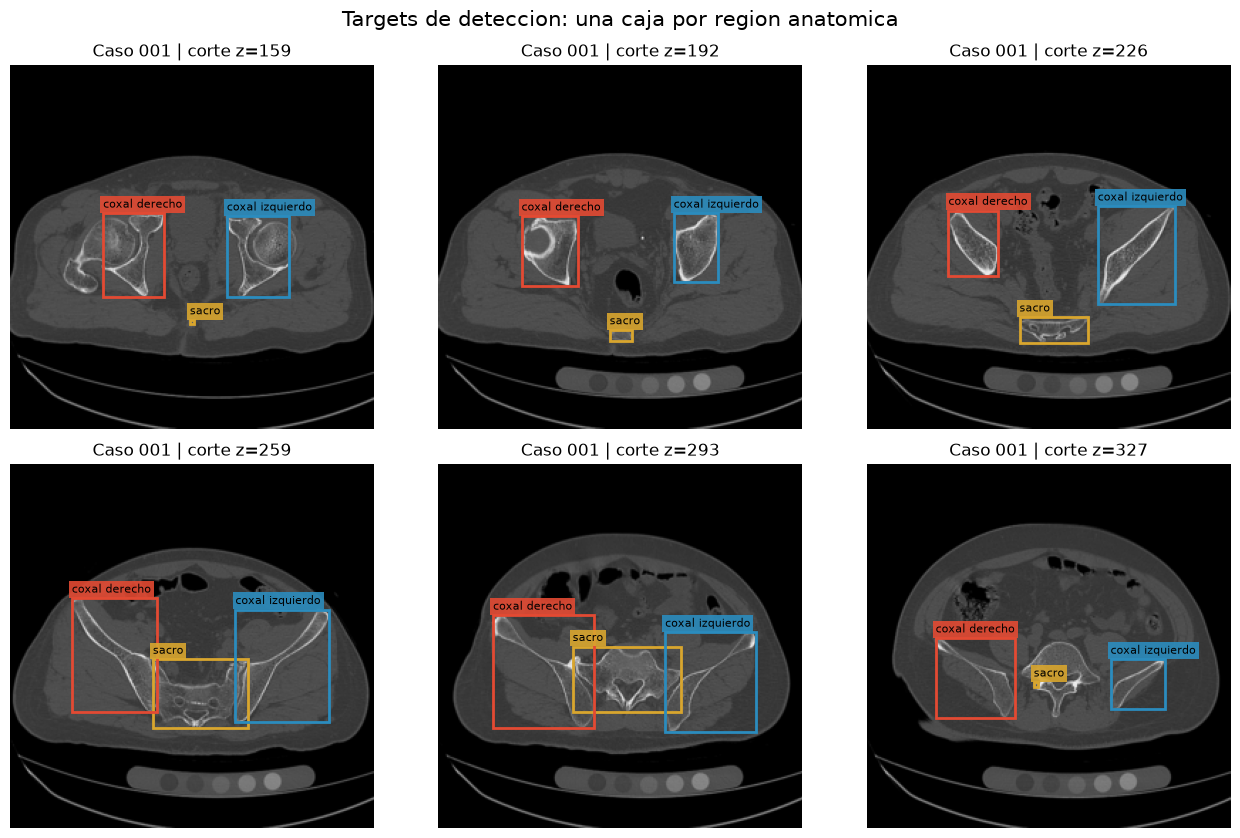

Evidencia guardada en: evidencias/datos_targets/targets_bounding_boxes_caso_001.png


In [25]:
# Evidencia visual de las cajas generadas
case_id_targets = splits["train"].iloc[0]["case_id"]
case_row = df[df["case_id"] == case_id_targets].iloc[0]
image_targets = sitk.GetArrayFromImage(
    sitk.ReadImage(str(resolve_repo_path(case_row["image_path"])))
).astype(np.float32)
label_targets = sitk.GetArrayFromImage(
    sitk.ReadImage(str(resolve_repo_path(case_row["label_path"])))
).astype(np.int16)

case_manifest = slice_manifest[
    (slice_manifest["case_id"] == case_id_targets) & (slice_manifest["n_regions"] == 3)
]
positions = np.linspace(0, len(case_manifest) - 1, 6).astype(int)
preview_slices = case_manifest.iloc[positions]["slice_index"].astype(int).tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for axis, slice_index in zip(axes.ravel(), preview_slices):
    image = apply_hu_window(image_targets[slice_index])
    image, label, transform = letterbox_pair(image, label_targets[slice_index], 256)
    scaled_min_pixels = max(1, int(round(20 * transform["scale"] ** 2)))
    target = build_detection_target(label, case_id_targets, slice_index, scaled_min_pixels)
    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    for box, class_id in zip(target["boxes"], target["labels"]):
        x_min, y_min, x_max, y_max = box
        color = TARGET_COLORS[int(class_id)]
        axis.add_patch(patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor=color, facecolor="none"
        ))
        axis.text(
            x_min, max(8, y_min - 4),
            CLASS_ID_TO_NAME[int(class_id)].replace("_", " "),
            fontsize=8, color="black",
            bbox={"facecolor": color, "alpha": 0.9, "pad": 2, "edgecolor": "none"},
        )
    axis.set_title(f"Caso {case_id_targets} | corte z={slice_index}")
    axis.axis("off")

fig.suptitle("Targets de deteccion: una caja por region anatomica", fontsize=15)
fig.tight_layout()
targets_preview_path = targets_dir / f"targets_bounding_boxes_caso_{case_id_targets}.png"
fig.savefig(targets_preview_path, dpi=180, bbox_inches="tight")
plt.show()
print("Evidencia guardada en:", to_repo_relative(targets_preview_path))

### 21.1 Dataset para integracion con el modelo

El dataset devuelve la imagen con forma `(canales, 256, 256)` y un diccionario con cajas `xyxy`, clases, areas, mascaras e identificadores. Puede producir NumPy o tensores PyTorch y usa un `collate` para cantidades variables de cajas.

In [26]:
class PengwinDetectionDataset:
    def __init__(self, split="train", image_size=256, channels=1, as_torch=False):
        if split not in {"train", "val", "test"}:
            raise ValueError("split debe ser train, val o test")
        if channels not in {1, 3}:
            raise ValueError("channels debe ser 1 o 3")
        self.image_size = image_size
        self.channels = channels
        self.as_torch = as_torch
        self.records = slice_manifest[slice_manifest["split"] == split][
            ["case_id", "slice_index"]
        ].to_dict("records")
        self._cached_case_id = None

    def __len__(self):
        return len(self.records)

    def _load_case(self, case_id):
        if case_id != self._cached_case_id:
            row = df[df["case_id"] == case_id].iloc[0]
            image_itk = sitk.ReadImage(str(resolve_repo_path(row["image_path"])))
            label_itk = sitk.ReadImage(str(resolve_repo_path(row["label_path"])))
            self._image = sitk.GetArrayFromImage(image_itk).astype(np.float32)
            self._label = sitk.GetArrayFromImage(label_itk).astype(np.int16)
            self._spacing = tuple(float(value) for value in image_itk.GetSpacing())
            self._cached_case_id = case_id
        return self._image, self._label, self._spacing

    def __getitem__(self, index):
        record = self.records[index]
        image_volume, label_volume, spacing = self._load_case(record["case_id"])
        image = apply_hu_window(image_volume[record["slice_index"]])
        image, label, transform = letterbox_pair(
            image, label_volume[record["slice_index"]], self.image_size
        )
        min_pixels = max(1, int(round(20 * transform["scale"] ** 2)))
        target = build_detection_target(
            label, record["case_id"], record["slice_index"], min_pixels
        )
        target["spacing_xyz_mm"] = spacing
        target["transform"] = transform
        image = image[None, ...]
        if self.channels == 3:
            image = np.repeat(image, 3, axis=0)
        image = image.astype(np.float32)

        if not self.as_torch:
            return image, target

        import torch
        tensor_target = {
            **target,
            "boxes": torch.from_numpy(target["boxes"]),
            "labels": torch.from_numpy(target["labels"]),
            "areas": torch.from_numpy(target["areas"]),
            "semantic_mask": torch.from_numpy(target["semantic_mask"].astype(np.int64)),
            "instance_mask": torch.from_numpy(target["instance_mask"].astype(np.int64)),
            "image_id": torch.tensor([index], dtype=torch.int64),
        }
        return torch.from_numpy(image), tensor_target


def detection_collate(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_detection_dataset = PengwinDetectionDataset(split="train", as_torch=False)
sample_image, sample_target = train_detection_dataset[0]
print("Cortes positivos de entrenamiento:", len(train_detection_dataset))
print("Forma de imagen:", sample_image.shape)
print("Forma de cajas:", sample_target["boxes"].shape)
print("Clases:", sample_target["class_names"])

Cortes positivos de entrenamiento: 18072
Forma de imagen: (1, 256, 256)
Forma de cajas: (1, 4)
Clases: ['coxal_izquierdo']
